E0000 00:00:1774442164.399492   98295 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1774442164.399528   98295 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1774442164.399530   98295 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1774442164.399531   98295 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1774442164.399532   98295 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, stores, sub_networks



BATTERY SUMMARY
--------------------------------------------------
Battery energy capacity [MWh]:      3857.44
Battery charging power [MW]:       1197.52
Battery discharging power [MW]:    1225.40
Storage duration [h]:              3.15


ValueError: When stacked is True, each column must be either all positive or all negative. Column 'battery' contains both positive and negative values

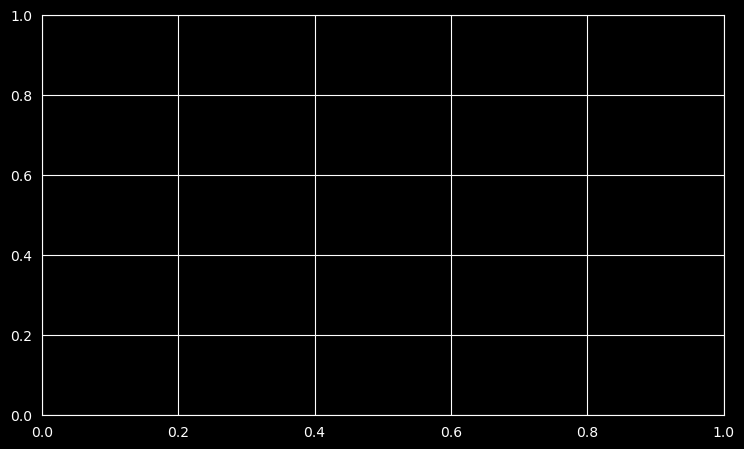

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pypsa

MODEL_PATH = "/home/tom/PycharmProjects/IES/results/dk_base_battery_network_2016.nc"
OUTPUT_DIR = Path("/home/tom/PycharmProjects/IES/results/storage_analysis")


def ensure_output_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def load_network(model_path: str) -> pypsa.Network:
    """
    Load solved PyPSA network.
    """
    return pypsa.Network(model_path)


def get_energy_balance_by_carrier(n: pypsa.Network) -> pd.DataFrame:
    """
    Return the time-resolved energy balance aggregated by carrier.
    """
    balance = n.statistics.energy_balance(aggregate_time=False)

    balance_by_carrier = balance.groupby(level="carrier").sum()
    balance_by_carrier_t = balance_by_carrier.T

    # Drop carriers that are all NaN
    balance_by_carrier_t = balance_by_carrier_t.dropna(axis=1, how="all")

    # Drop carriers that are zero everywhere
    balance_by_carrier_t = balance_by_carrier_t.loc[
        :, (balance_by_carrier_t.fillna(0).abs() > 0).any(axis=0)
    ]

    return balance_by_carrier_t


def plot_full_year_energy_balance(balance_by_carrier_t: pd.DataFrame, output_dir: Path) -> None:
    """
    Plot full-year system energy balance by carrier.
    """
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    balance_by_carrier_t.plot.area(stacked=True, ax=ax)

    ax.set_ylabel("Power balance [MW]", fontsize=12)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_title("System energy balance by carrier", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=10, ncol=2)
    plt.tight_layout()
    fig.savefig(output_dir / "energy_balance_full_year.pdf", bbox_inches="tight")
    plt.close(fig)


def plot_energy_balance_week(
    balance_by_carrier_t: pd.DataFrame,
    start_date: str,
    end_date: str,
    output_path: Path,
    title: str,
) -> None:
    """
    Plot one representative week of the system energy balance.
    """
    week_balance = balance_by_carrier_t.loc[start_date:end_date]

    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    week_balance.plot.area(stacked=True, ax=ax)

    ax.set_ylabel("Power balance [MW]", fontsize=12)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def plot_battery_soc(n: pypsa.Network, output_dir: Path) -> None:
    """
    Plot the full-year battery state of charge.
    """
    soc = n.stores_t.e["DK_battery_store"]

    fig, ax = plt.subplots(figsize=(8.8, 4.5))
    ax.plot(soc.index, soc, linewidth=1.2)

    ax.set_ylabel("State of charge [MWh]", fontsize=12)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_title("Battery state of charge over the full year", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(output_dir / "battery_soc_full_year.pdf", bbox_inches="tight")
    plt.close(fig)


def print_battery_summary(n: pypsa.Network) -> None:
    """
    Print key battery metrics.
    """
    energy_capacity = n.stores.at["DK_battery_store", "e_nom_opt"]
    charge_capacity = n.links.at["DK_battery_charger", "p_nom_opt"]
    discharge_capacity = n.links.at["DK_battery_discharger", "p_nom_opt"]
    duration_hours = energy_capacity / discharge_capacity if discharge_capacity > 0 else float("nan")

    print("\nBATTERY SUMMARY")
    print("-" * 50)
    print(f"Battery energy capacity [MWh]:      {energy_capacity:.2f}")
    print(f"Battery charging power [MW]:       {charge_capacity:.2f}")
    print(f"Battery discharging power [MW]:    {discharge_capacity:.2f}")
    print(f"Storage duration [h]:              {duration_hours:.2f}")


def main() -> None:
    ensure_output_dir(OUTPUT_DIR)

    n = load_network(MODEL_PATH)

    balance_by_carrier_t = get_energy_balance_by_carrier(n)

    print_battery_summary(n)

    plot_full_year_energy_balance(balance_by_carrier_t, OUTPUT_DIR)

    plot_energy_balance_week(
        balance_by_carrier_t=balance_by_carrier_t,
        start_date="2016-06-13",
        end_date="2016-06-19 23:00:00",
        output_path=OUTPUT_DIR / "energy_balance_summer_week.pdf",
        title="System energy balance during a representative summer week",
    )

    plot_energy_balance_week(
        balance_by_carrier_t=balance_by_carrier_t,
        start_date="2016-01-11",
        end_date="2016-01-17 23:00:00",
        output_path=OUTPUT_DIR / "energy_balance_winter_week.pdf",
        title="System energy balance during a representative winter week",
    )

    plot_battery_soc(n, OUTPUT_DIR)

    print("\nSaved plots to:")
    for file in sorted(OUTPUT_DIR.glob("*.pdf")):
        print(file)


if __name__ == "__main__":
    main()